# Project #3 Task 3  NON-LINEAR REGRESSION WITH SCIPY OPTIMIZE

Introduction

Depending on the trend of the dataset, we will model

    a) Polymonial function

    b) Logarithmic function

    c) Exponential function

    d) Power function






# Abstract

# Introduction 

# Non-Linear Regression modeling 




In [5]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit



In [17]:
# Load the data
df = pd.read_excel('CleanedFeatureSelected.xlsx')

# step 1 :Plot and define the suggested functions

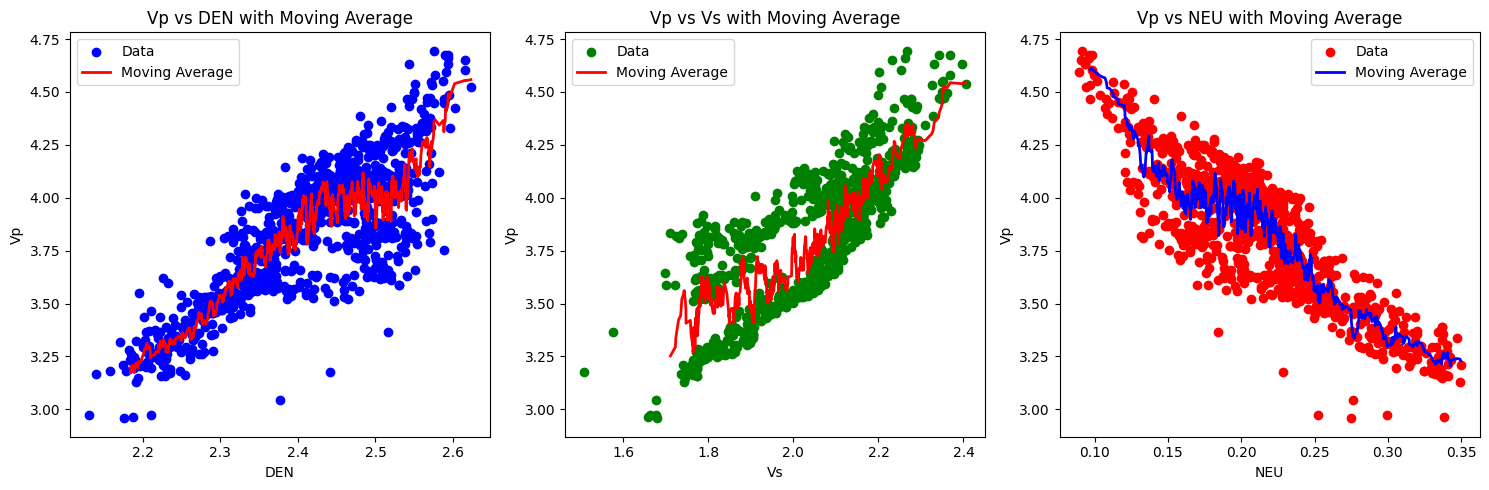

In [18]:

# Define the window size for the moving average
window_size = 10  # Adjust as needed

# Sort the DataFrame by each x-variable to ensure a smooth moving average line
df_sorted_den = df.sort_values(by='DEN')
df_sorted_vs = df.sort_values(by='Vs')
df_sorted_neu = df.sort_values(by='NEU')

# Calculate the moving average for each sorted DataFrame
df_sorted_den['Vp_MA'] = df_sorted_den['Vp'].rolling(window=window_size).mean()
df_sorted_vs['Vp_MA'] = df_sorted_vs['Vp'].rolling(window=window_size).mean()
df_sorted_neu['Vp_MA'] = df_sorted_neu['Vp'].rolling(window=window_size).mean()

# Plot each scatter plot with the moving average line
plt.figure(figsize=(15, 5))

# Vp vs DEN with moving average
plt.subplot(1, 3, 1)
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(df_sorted_den['DEN'], df_sorted_den['Vp_MA'], color='red', linewidth=2, label='Moving Average')
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title('Vp vs DEN with Moving Average')
plt.legend()

# Vp vs Vs with moving average
plt.subplot(1, 3, 2)
plt.scatter(df['Vs'], df['Vp'], color='green', label='Data')
plt.plot(df_sorted_vs['Vs'], df_sorted_vs['Vp_MA'], color='red', linewidth=2, label='Moving Average')
plt.xlabel('Vs')
plt.ylabel('Vp')
plt.title('Vp vs Vs with Moving Average')
plt.legend()

# Vp vs NEU with moving average
plt.subplot(1, 3, 3)
plt.scatter(df['NEU'], df['Vp'], color='red', label='Data')
plt.plot(df_sorted_neu['NEU'], df_sorted_neu['Vp_MA'], color='blue', linewidth=2, label='Moving Average')
plt.xlabel('NEU')
plt.ylabel('Vp')
plt.title('Vp vs NEU with Moving Average')
plt.legend()

plt.tight_layout()
plt.show()


From the plots :
1. Vp vs DEN: The relationship between Vp and DEN appears mostly linear, with Vp increasing gradually as DEN increases. So it would be best to use a first degree polynomial function here.

2. Vp vs Vs: This plot shows a more pronounced curve in the relationship, indicating that a polynomial function would likely be a better fit than a simple linear model. A second-degree polynomial should help model this non-linearity effectively.

3. Vp vs NEU: Unlike the previous two, Vp and NEU exhibit a strong negative relationship, with Vp decreasing as NEU increases. The downward trend suggests that a negative power function would be suitable to capture this inverse relationship.

In [19]:
# Define a first degree polynomial function for Vp vs DEN
def Vp_DEN(x, a, b):
    return a * x + b

# Define a second degree polynomial function  for Vp vs Vs
def Vp_Vs(x, a, b, c):
    return a * x**2 + b * x + c

# Define a negative power function for Vp vs NEU
def Vp_NEU(x, a, b):
    return a * np.power(x, -b)

# step 2 : Unpack the cofficients

In [20]:
# Fit linear to Vp vs DEN using df['DEN'] and df['Vp'] directly
params_den, _ = curve_fit(Vp_DEN, df['DEN'], df['Vp'])
a_den, b_den = params_den

# Fit polynomial to Vp vs Vs using df['Vs'] and df['Vp'] directly
params_vs, _ = curve_fit(Vp_Vs, df['Vs'], df['Vp'])
a_vs, b_vs, c_vs = params_vs

# Fit negative power function to Vp vs NEU using df['NEU'] and df['Vp'] directly
params_neu, _ = curve_fit(Vp_NEU, df['NEU'], df['Vp'])
a_neu, b_neu = params_neu

# Display optimized parameters
print(f"Optimized parameters for Vp vs DEN : a = {a_den}, b = {b_den}")
print(f"Optimized parameters for Vp vs Vs : a = {a_vs}, b = {b_vs}, c = {c_vs}")
print(f"Optimized parameters for Vp vs NEU : a = {a_neu}, b = {b_neu}")

Optimized parameters for Vp vs DEN (Linear): a = 2.550977349584728, b = -2.3107834981778193
Optimized parameters for Vp vs Vs (Polynomial): a = 1.941411612105004, b = -6.162785248908854, c = 8.263744451964154
Optimized parameters for Vp vs NEU (Negative Power): a = 2.531718160483608, b = 0.2614983539637239


# Step 3 : Predicting Vp value and Comparing with the actual Vp value

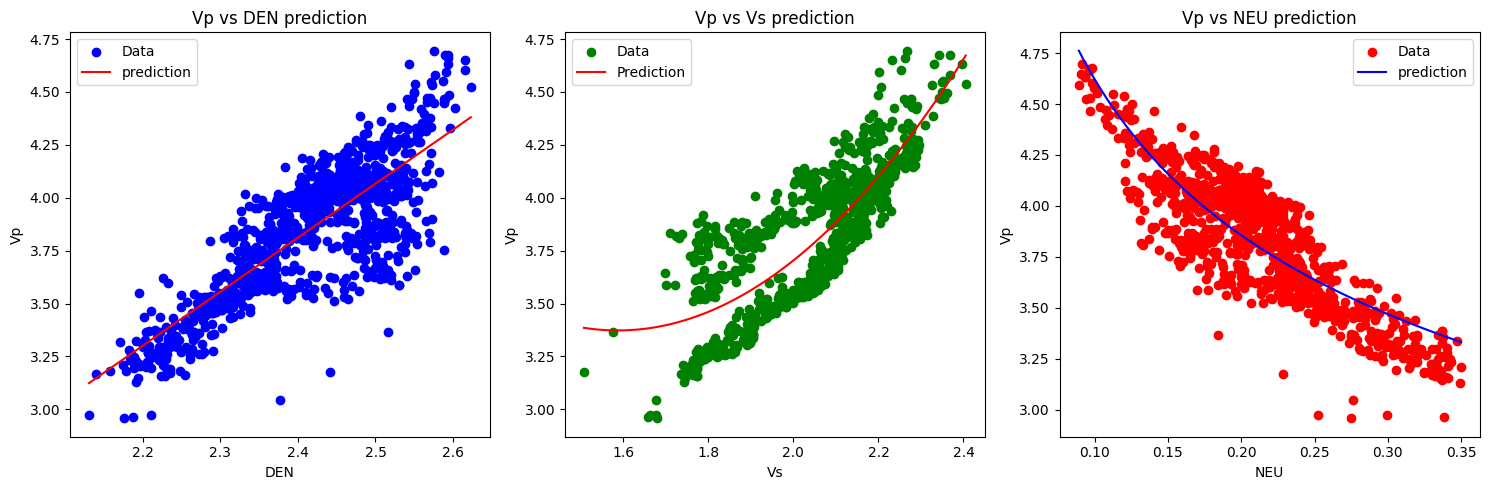

In [23]:

# Generate x-values for smooth curve plotting within the range of each predictor
x_values_den = np.linspace(df['DEN'].min(), df['DEN'].max(), 100)
x_values_vs = np.linspace(df['Vs'].min(), df['Vs'].max(), 100)
x_values_neu = np.linspace(df['NEU'].min(), df['NEU'].max(), 100)

# Calculate the fitted y-values (predictions) using the models
y_model_predicted_den = Vp_DEN(x_values_den, a_den, b_den)
y_model_predicted_vs = Vp_Vs(x_values_vs, a_vs, b_vs, c_vs)
y_model_predicted_neu = Vp_NEU(x_values_neu, a_neu, b_neu)

# Plot Vp vs DEN with model fit line
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(x_values_den, y_model_predicted_den, color='red', label='prediction')
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title('Vp vs DEN prediction')
plt.legend()

# Plot Vp vs Vs with model fit line
plt.subplot(1, 3, 2)
plt.scatter(df['Vs'], df['Vp'], color='green', label='Data')
plt.plot(x_values_vs, y_model_predicted_vs, color='red', label='Prediction')
plt.xlabel('Vs')
plt.ylabel('Vp')
plt.title('Vp vs Vs prediction')
plt.legend()

# Plot Vp vs NEU with model fit line
plt.subplot(1, 3, 3)
plt.scatter(df['NEU'], df['Vp'], color='red', label='Data')
plt.plot(x_values_neu, y_model_predicted_neu, color='blue', label='prediction')
plt.xlabel('NEU')
plt.ylabel('Vp')
plt.title('Vp vs NEU prediction')
plt.legend()

plt.tight_layout()
plt.show()


each prediction align pretty good with the real data suggesting the choosen functions are appropriate for the data pairs.

# Step 4 : Compute Regression coefficient

In [26]:
y_model_predicted_den = Vp_DEN(df['DEN'], a_den, b_den)
y_model_predicted_vs = Vp_Vs(df['Vs'], a_vs, b_vs, c_vs)
y_model_predicted_neu = Vp_NEU(df['NEU'], a_neu, b_neu)

# Calculate R² score for each model
r2_den = r2_score(df['Vp'], y_model_predicted_den)
r2_vs = r2_score(df['Vp'], y_model_predicted_vs)
r2_neu = r2_score(df['Vp'], y_model_predicted_neu)

# Print the regression coefficients and R² scores
print("Regression Coefficients and R² Scores:")
print(f"Vp vs DEN : Coefficients = (a: {a_den:.3g}, b: {b_den:.3g}), R² = {r2_den:.3g}")
print(f"Vp vs Vs : Coefficients = (a: {a_vs:.3g}, b: {b_vs:.3g}, c: {c_vs:.3g}), R² = {r2_vs:.3g}")
print(f"Vp vs NEU : Coefficients = (a: {a_neu:.3g}, b: {b_neu:.3g}), R² = {r2_neu:.3g}")

Regression Coefficients and R² Scores:
Vp vs DEN : Coefficients = (a: 2.55, b: -2.31), R² = 0.674
Vp vs Vs : Coefficients = (a: 1.94, b: -6.16, c: 8.26), R² = 0.679
Vp vs NEU : Coefficients = (a: 2.53, b: 0.261), R² = 0.71


From the Regression coefficient results we can see that Vp vs NEU model is the most accurate at prediction since it had highest value of reggression coefficients among them So we will take that model and compare it to Gardner's model and see if it outperformes Gardner's model.Based on the regression coefficients and R² scores, the Vp vs NEU model appears to be the most accurate among the fitted models, with the highest R² value of 0.71. This suggests that the Vp vs NEU model captures more variance in the data compared to the other models (Vp vs DEN and Vp vs Vs). As a next step, we’ll compare this Vp vs NEU model with Gardner’s model to determine if it provides a better fit for predicting Vp.

# Step 5 : Comparison to Gardner's model

## Gardner's model [1]
Is a popular function that relates bulk density (DEN) and P-wave velocity and is very popular in petroleum exploration. The function goes as :

$$\rho = 0.31 V_p^{0.25}$$

In order to use this function for our case we have to rewrite it so that the function solves for V_p.

solving for Vp:

$$V_p = \left( \frac{\rho}{0.31} \right)^4$$

Gardner's Model R² = -48


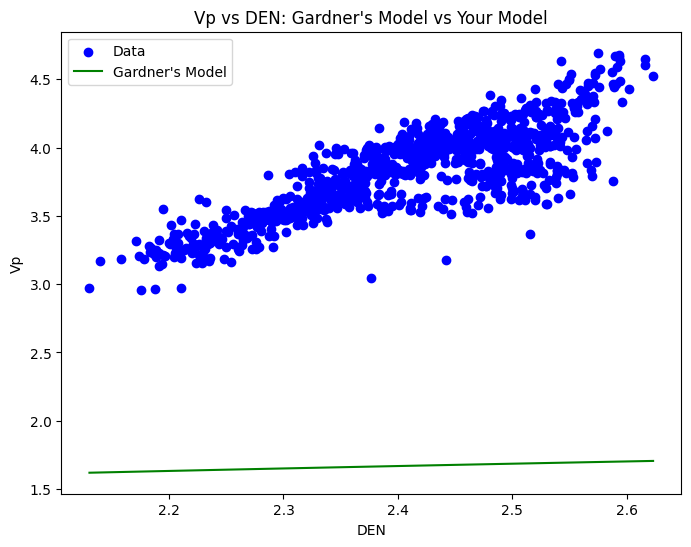

In [29]:
def gardner_model(den, a=0.31, b=0.25):
    return (den/a)**b

# Apply Gardner's model to calculate predicted Vp values
y_gardner_pred = gardner_model(df['DEN'])

# Calculate R² score for Gardner's model
r2_gardner = r2_score(df['Vp'], y_gardner_pred)

# Compare with your model's R² score for Vp vs DEN (Linear Model)

print(f"Gardner's Model R² = {r2_gardner:.3g}")

x_values_den = np.linspace(df['DEN'].min(), df['DEN'].max(), 100)
y_gardner_fit = gardner_model(x_values_den)

# Plot original data, Gardner's model, and your linear model fit
plt.figure(figsize=(8, 6))
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(x_values_den, y_gardner_fit, color='green', label="Gardner's Model")
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title("Vp vs DEN: Gardner's Model vs Your Model")
plt.legend()
plt.show()

# Discussion 


# Reflection 

# References
[1] : (https://en.wikipedia.org/wiki/Gardner%27s_relation)
